# Лабароторная работа 2

## 1.1 Оценки математического ожидания, дисперсии, медианы

### Задача 1


Пусть случайная величина ξ имеет распределение, задаваемое плотностью fξ(x) = θ2xe−θx. Для каждого θ ∈ {0.5, 2, 8}:
1

(a) Аналитически вычислить математическое ожидание, дисперсию и
математическое ожидание квадрата ξ. Привести в отчет.

(b) Для k ∈ {24, 25, . . . , 215} построить выборку из k элементов. Для
каждой из них посчитать оценки: математического ожидания, дис-
персии и квадрата математического ожидания параметра из вари-
анта. Для каждой из выборок и оценок визуализировать это все
на графиках (для каждой оценки — свой график), где по верти-
кальной оси — оценка, а по горизонтальной — k, плюс, добавьте
горизонтальную линию, отвечающую за аналитически полученную
оценку.

#### (а) **Аналитическое решение**

Наше распределение - это частный случай Гамма-распределения. В Гамма-распределении есть 2 параметра - shape (k, для нашего случая = 2), а также параметр интенсивности (rate) - равен $(\theta$).

Для Гамма-распределения известны формулы **мат. ожидания и дисперсии**:

$$
\mathbb{E}[X] = \frac{k}{\theta} \qquad
\mathrm{Var}(X) = \frac{k}{\theta^2}
$$

Подставив значения из условия, **получим:**

$$
\mathbb{E}[X] = \frac{2}{\theta}, \qquad
\mathrm{Var}(X) = \frac{2}{\theta^2}
$$

**Мат. ожидание квадрата** можем найти из равенства:

$$
\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2
$$

Оно будет **равно**:

$$
\mathbb{E}[X^2] = \mathrm{Var}(X) + (\mathbb{E}[X])^2 = \frac{2}{\theta^2} + \frac{4}{\theta^2} = \frac{6}{\theta^2}
$$

Составим таблицу для **приведенных значений $\theta$**:

| $\theta$ | $E[X]$  | $D(X)$ | $E[X]$ |
|----------|------------|----------|------------|
| 0.5      | 4.0        | 8.0      | 24.0       |
| 2        | 1.0        | 0.5      | 1.5        |
| 8        | 0.2500     | 0.03125  | 0.09375    |


#### (b) **Создаем выборку из k элементов**




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
thetas = [0.5, 2, 8]
k_pow = np.arange(4, 16)
k_val = 2 ** k_pow

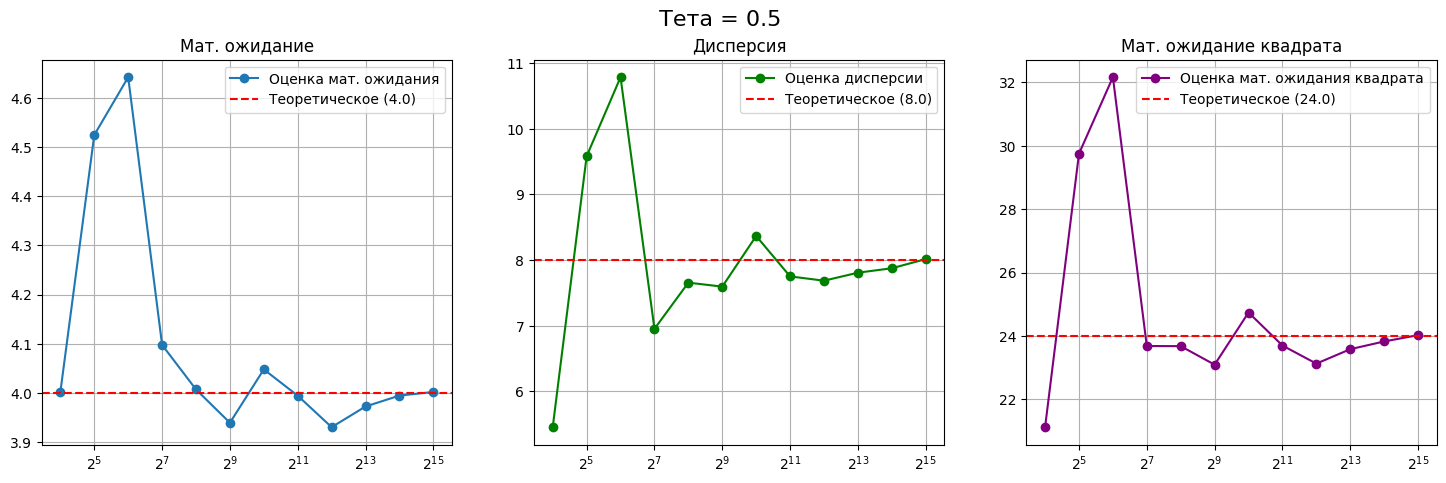

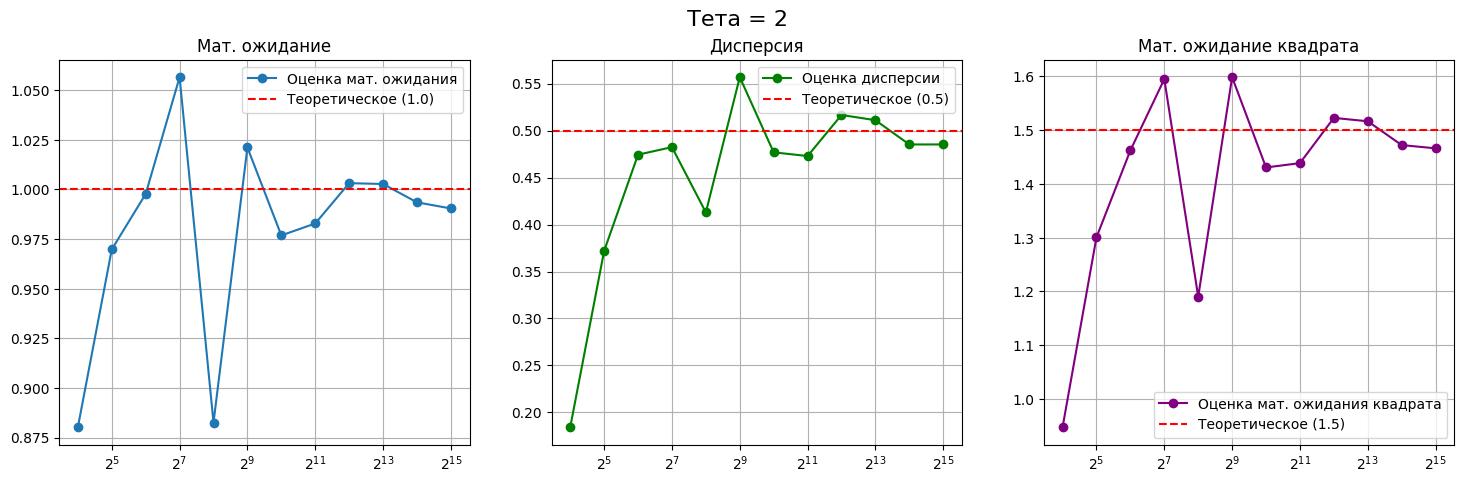

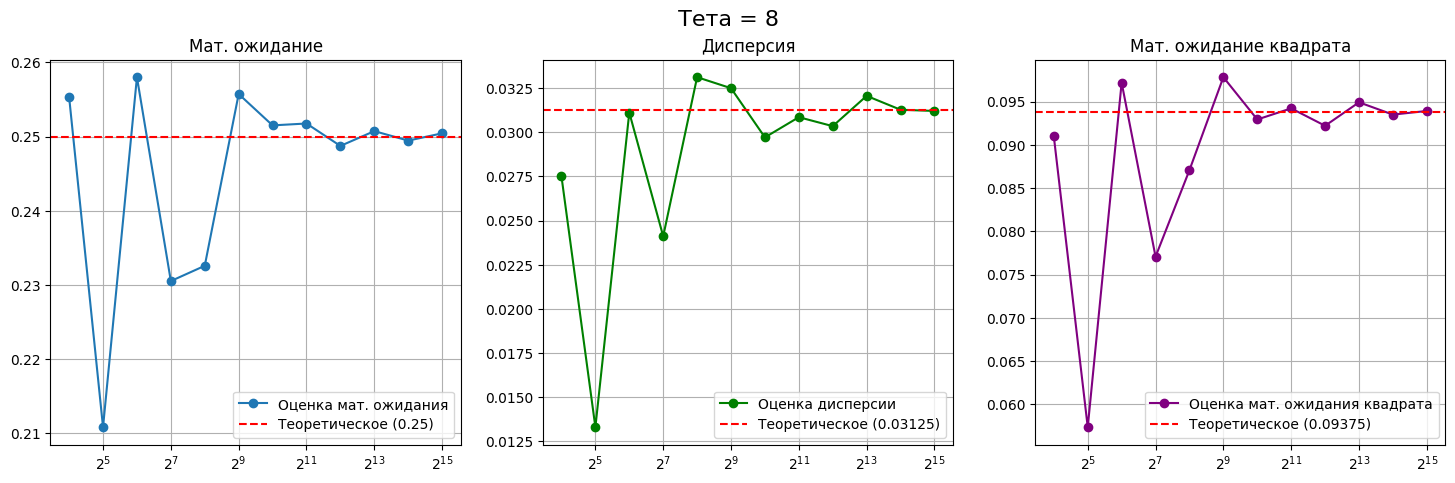

In [ ]:
for theta in thetas:
    mean = 2 / theta
    var = 2 / (theta ** 2)
    sq_mean = 6 / (theta ** 2)

    est_means = []
    est_vars = []
    est_sq_means = []

    for k in k_val:
        sample = np.random.gamma(shape=2, scale=1/theta, size=k)

        est_mean = np.mean(sample)
        est_var = np.var(sample, ddof=1)
        est_sq_mean = np.mean(sample ** 2)

        est_means.append(est_mean)
        est_vars.append(est_var)
        est_sq_means.append(est_sq_mean)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f' Тета = {theta}', fontsize=16)

    # Оценка мат. ожидания
    axs[0].plot(k_val, est_means, 'o-', label='Оценка мат. ожидания')
    axs[0].axhline(y=mean, color='r', linestyle='--', label=f'Теоретическое ({mean})')
    axs[0].set_xscale('log', base=2)
    axs[0].set_title('Мат. ожидание')
    axs[0].legend()
    axs[0].grid(True)

    # Оценка дисперсии
    axs[1].plot(k_val, est_vars, 'o-', label='Оценка дисперсии', color='green')
    axs[1].axhline(y=var, color='r', linestyle='--', label=f'Теоретическое ({var})')
    axs[1].set_xscale('log', base=2)
    axs[1].set_title('Дисперсия')
    axs[1].legend()
    axs[1].grid(True)

    # Оценка мат. ожидания квадрата
    axs[2].plot(k_val, est_sq_means, 'o-', label='Оценка мат. ожидания квадрата', color='purple')
    axs[2].axhline(y=sq_mean, color='r', linestyle='--', label=f'Теоретическое ({sq_mean})')
    axs[2].set_xscale('log', base=2)
    axs[2].set_title('Мат. ожидание квадрата')
    axs[2].legend()
    axs[2].grid(True)

    plt.show()

### Задача 2

Дана плотность распределения случайной величины ξ:

$$
f_\xi(x) =
\begin{cases}
\lambda e^{-\lambda (x-a)}, & x \geqslant a \\
0, & \text{else}
\end{cases}
$$

Пусть (λ, a) = (2, 2)


(a) Аналитически вычислите значение моды, математического ожидания и медианы.

(b) Создайте две выборки: одну довольно большого размера (10000
наблюдений, например), а вторую маленькую (например, 20). По-
стройте оценки моды, математического жидания и медианы.

(c) Постройте для первой выборки на одном графике: гистограмму
распределения значений из выборки и три вертикальных линии
оценок моды, математического ожидания и медианы. Для второй
выборки сделайте то же самое. Постройте ещё график рядом для
первой выборки, но с функцией распределения плотности и анали-
тическими значениями мод, математического жидания и медианы.
То же самое, для второй.

(d) Попробуйте поизменять размер выборки и посмотреть на то, на-
пример, сходится ли медиана к математическому ожиданию, или
нет.

#### (a) **Аналитически вычисляем моду, мат. ожидание и медиану** *Курсив*

**Мода**

У экспоненциальной функции распределения всегда находится в минимальной точке. В нашем случае минимум - это 2

$$
{\mathrm{Mo}[X] = 2}
$$

**Мат. ожидание**

У обычного экспоненциального распределения мат. ожидание равно $\frac{1}{\lambda}$

У нас есть смещение a, значит

$$
{\mathbb{E}[X] = a + \frac{1}{\lambda}} = 2 + \frac{1}{2} = 2.5
$$

**Медиана**

Чтобы найти медиану, нужно чтобы значение функции распределения было равно 0.5:

$$
F(x) = 1 - e^{-\lambda(x-a)}
$$

$$
1 - e^{-2(Me-2)} = 0.5
$$

$$
-2(Me-2) = \ln 0.5
$$

$$
Me[X] = 2.34657
$$


#### (b) **Создаем выборки**

In [ ]:
lam = 2
a = 2

In [ ]:
t_mode = 2
t_mean = 2.5
t_med = 2 + np.log(2)/2 # ~2.346

In [ ]:
n1 = 10000
n2 = 20
s1 = np.random.exponential(scale=1/lam, size=n1) + a
s2 = np.random.exponential(scale=1/lam, size=n2) + a

In [ ]:
print(f"Большая выборка: Mode={np.min(s1):.3f}, Mean={np.mean(s1):.3f}, Med={np.median(s1):.3f}")
print(f"Маленькая выборка: Mode={np.min(s2):.3f}, Mean={np.mean(s2):.3f}, Med={np.median(s2):.3f}")

Большая выборка: Mode=2.000, Mean=2.493, Med=2.344
Маленькая выборка: Mode=2.047, Mean=2.566, Med=2.273


#### (c) **Визуализация и сравнение с теор. значениями** *Курсив*

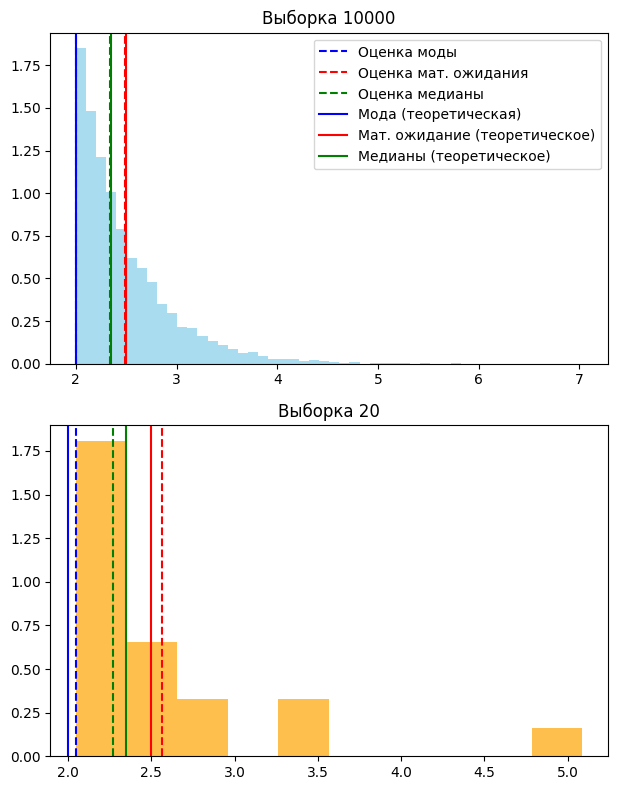

In [ ]:
plt.figure(figsize=(12, 8))

x = np.linspace(2, 5, 100)
y = lam * np.exp(-lam * (x - a))

# Большая выборка
plt.subplot(2, 2, 1)
plt.hist(s1, bins=50, density=True, color='skyblue', alpha=0.7)
plt.axvline(np.min(s1), c='b', ls='--', label='Оценка моды')
plt.axvline(np.mean(s1), c='r', ls='--', label='Оценка мат. ожидания')
plt.axvline(np.median(s1), c='g', ls='--', label='Оценка медианы')
plt.axvline(t_mode, c='b', label='Мода (теоретическая)')
plt.axvline(t_mean, c='r', label='Мат. ожидание (теоретическое)')
plt.axvline(t_med, c='g', label='Медианы (теоретическое)')
plt.legend(); plt.title(f'Выборка {n1}')

# Маленькая выборка
plt.subplot(2, 2, 3)
plt.hist(s2, bins=10, density=True, color='orange', alpha=0.7)
plt.axvline(np.min(s2), c='b', ls='--')
plt.axvline(np.mean(s2), c='r', ls='--')
plt.axvline(np.median(s2), c='g', ls='--')
plt.axvline(t_mode, c='b')
plt.axvline(t_mean, c='r')
plt.axvline(t_med, c='g')
plt.title(f'Выборка {n2}')

plt.tight_layout()
plt.show()

#### (d) **Анализ на сходимость**

Сходимость будет только при больших числах в выборке

Чем больше выборка - тем ближе будут теоретические значения к выборочным

## 1.2 Моделирование совместного распределения двух СВ

$$
\begin{aligned}
1. \quad & P(\xi, \eta) = P(\xi) \cdot P(\eta). \\
& \text{Для } \eta \text{ (столбцы): множитель } \frac{1}{2^k}. \quad \sum_{k=1}^{\infty} \frac{1}{2^k} = 1. \\
& \text{Для } \xi \text{ (строки): множители } \frac{2}{5}, \frac{1}{5}, \frac{2}{5}. \text{ Сумма } = 1. \\
2. \quad & \text{Так как } P(\xi=x, \eta=y) = P(\xi=x) \cdot P(\eta=y), \text{ то } \xi \text{ и } \eta \text{ независимы.} \\
3. \quad & \text{Из независимости } \implies \text{cov}(\xi, \eta) = 0 \implies \rho = 0. \\
4. \quad & \text{Корреляционная матрица: } \Sigma = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}.
\end{aligned}
$$


In [ ]:
N = 10000000

xi = np.random.choice([-1, 0, 1], p=[0.4, 0.2, 0.4], size=N)

eta = np.random.geometric(p=0.5, size=N)

corr_matrix = np.corrcoef(xi, eta)

print("Аналитическая матрица:")
print("[[1 0]")
print(" [0 1]]")
print("\nНаша оценка:")
print(corr_matrix)

Аналитическая матрица:
[[1 0]
 [0 1]]

Наша оценка:
[[ 1.00000000e+00 -3.23164364e-04]
 [-3.23164364e-04  1.00000000e+00]]
